<a href="https://colab.research.google.com/github/sreelakshmisajeevan-854/Glass-Classification-Using-Random-Forest/blob/main/Glass-Classification-Using-Random-Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_excel('/content/drive/MyDrive/Datasets/glass.xlsx',sheet_name='glass')

# 1. Exploratory Data Analysis (EDA):

In [ ]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
df.shape

(214, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [ ]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
for col in df.columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  print(f"{col} : {iqr}")

RI : 0.002634999999999943
Na : 0.9174999999999986
Mg : 1.4850000000000003
Al : 0.43999999999999995
Si : 0.8075000000000045
K : 0.4875
Ca : 0.9324999999999992
Ba : 0.0
Fe : 0.1
Type : 2.0


Inferences

*   The Glass dataset contains 214 observations and 9 numerical features.

*   There are only numerical values
*   There are no missing values, but one duplicate record is present.
*  Several features contain potential outliers, particularly Mg and Ca.

*  The target variable is 'Type' of datatype int.






# 2: Data Visualization:

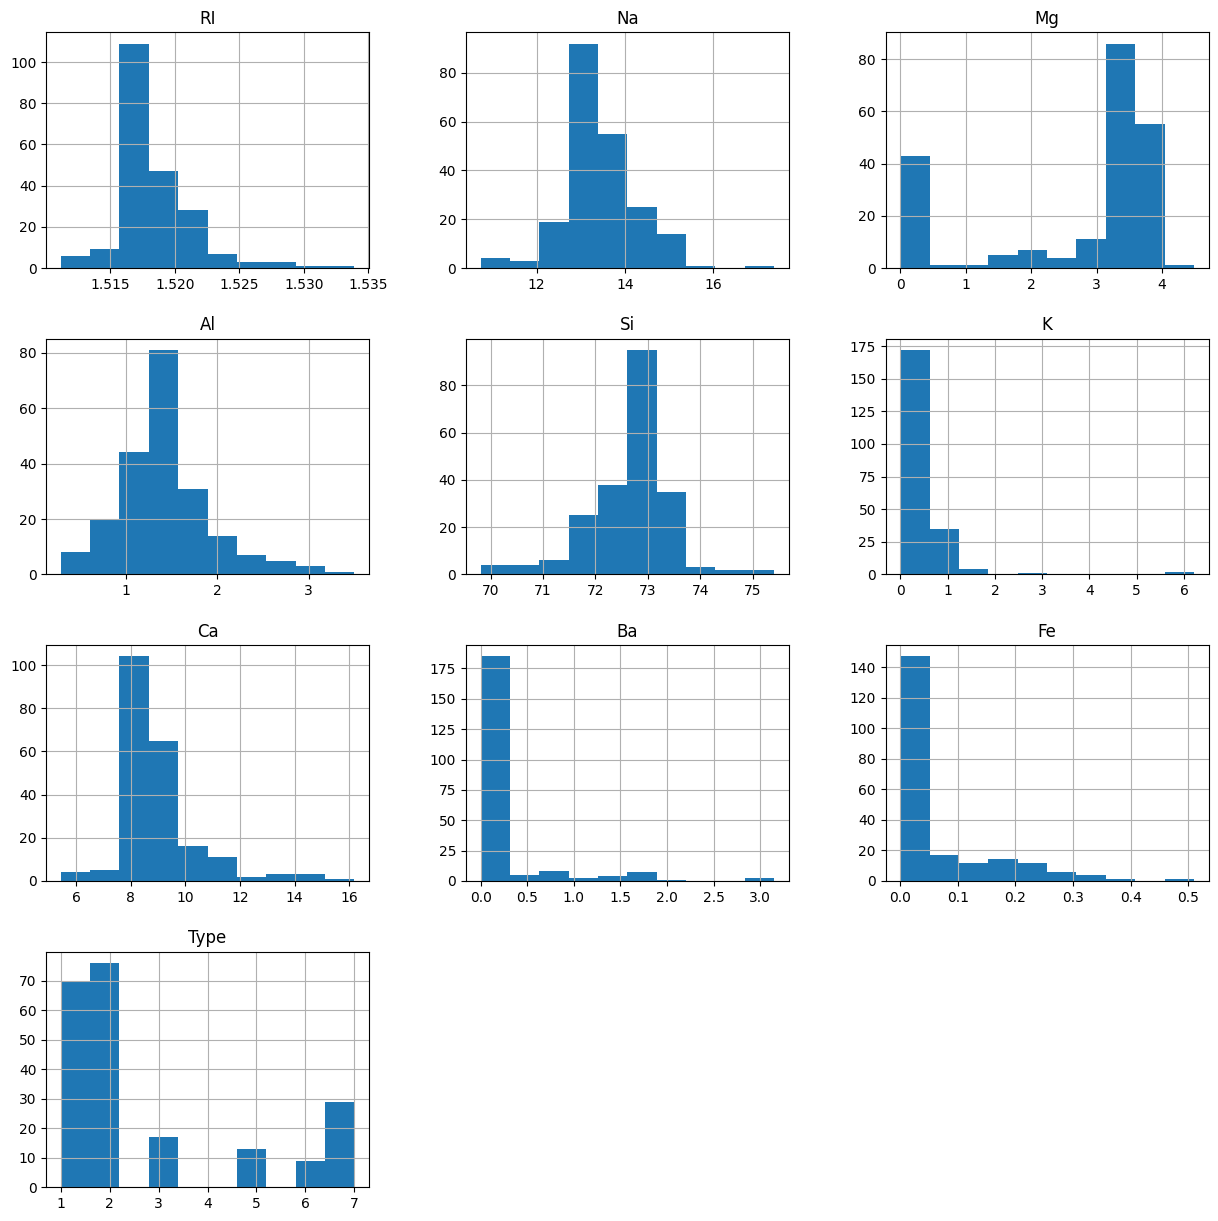

In [ ]:
df.hist(figsize=(15,15))
plt.show()

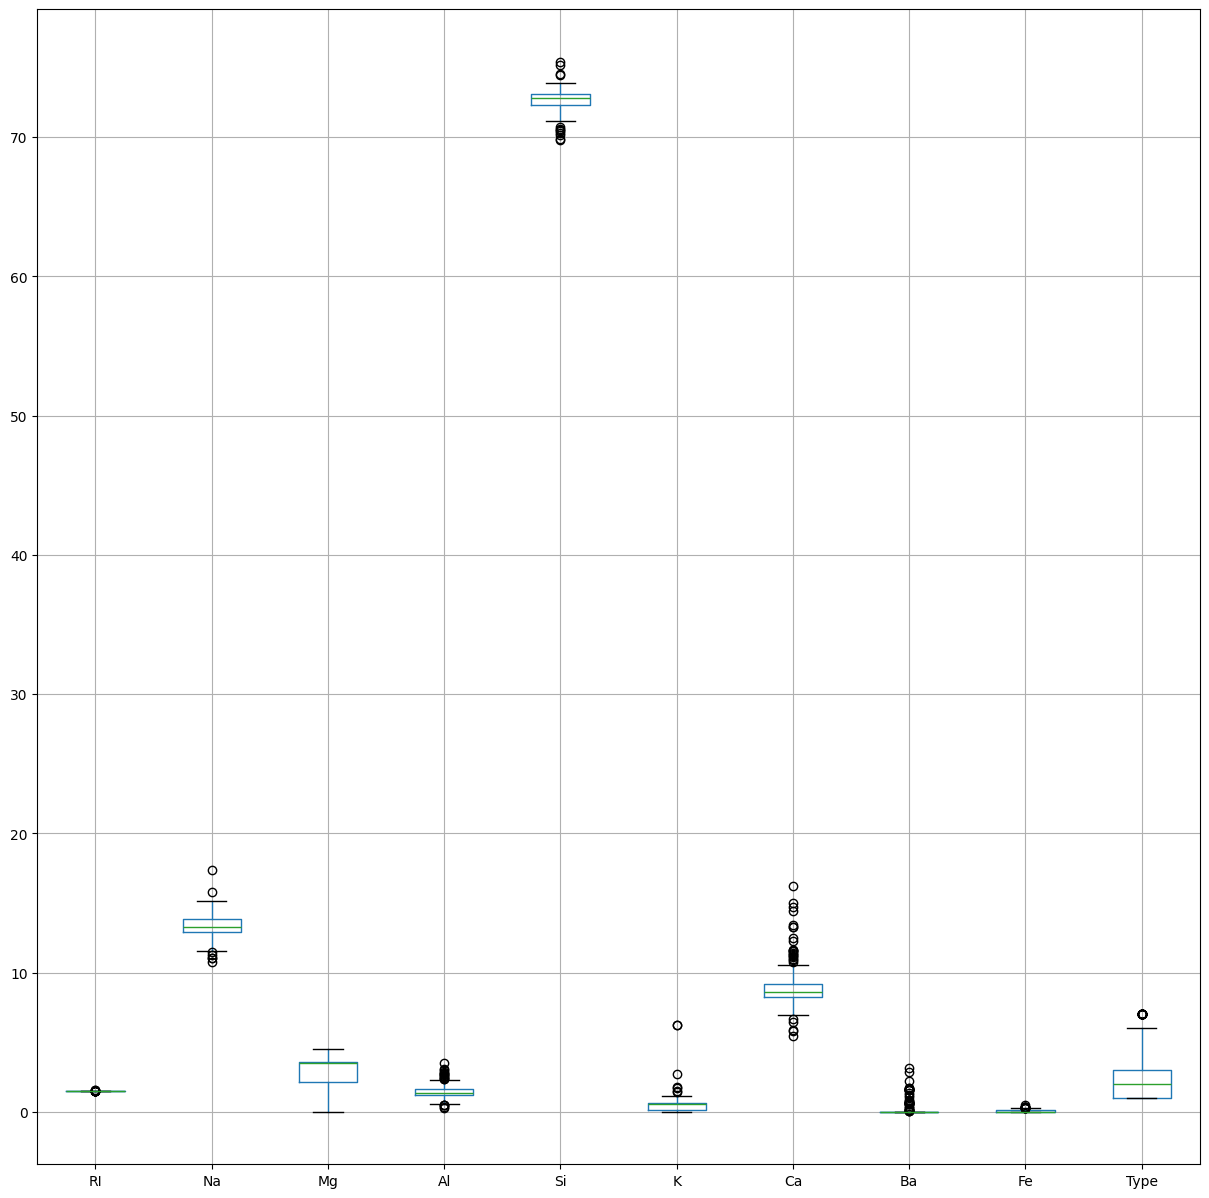

In [ ]:
df.boxplot(figsize=(15,15))
plt.show()

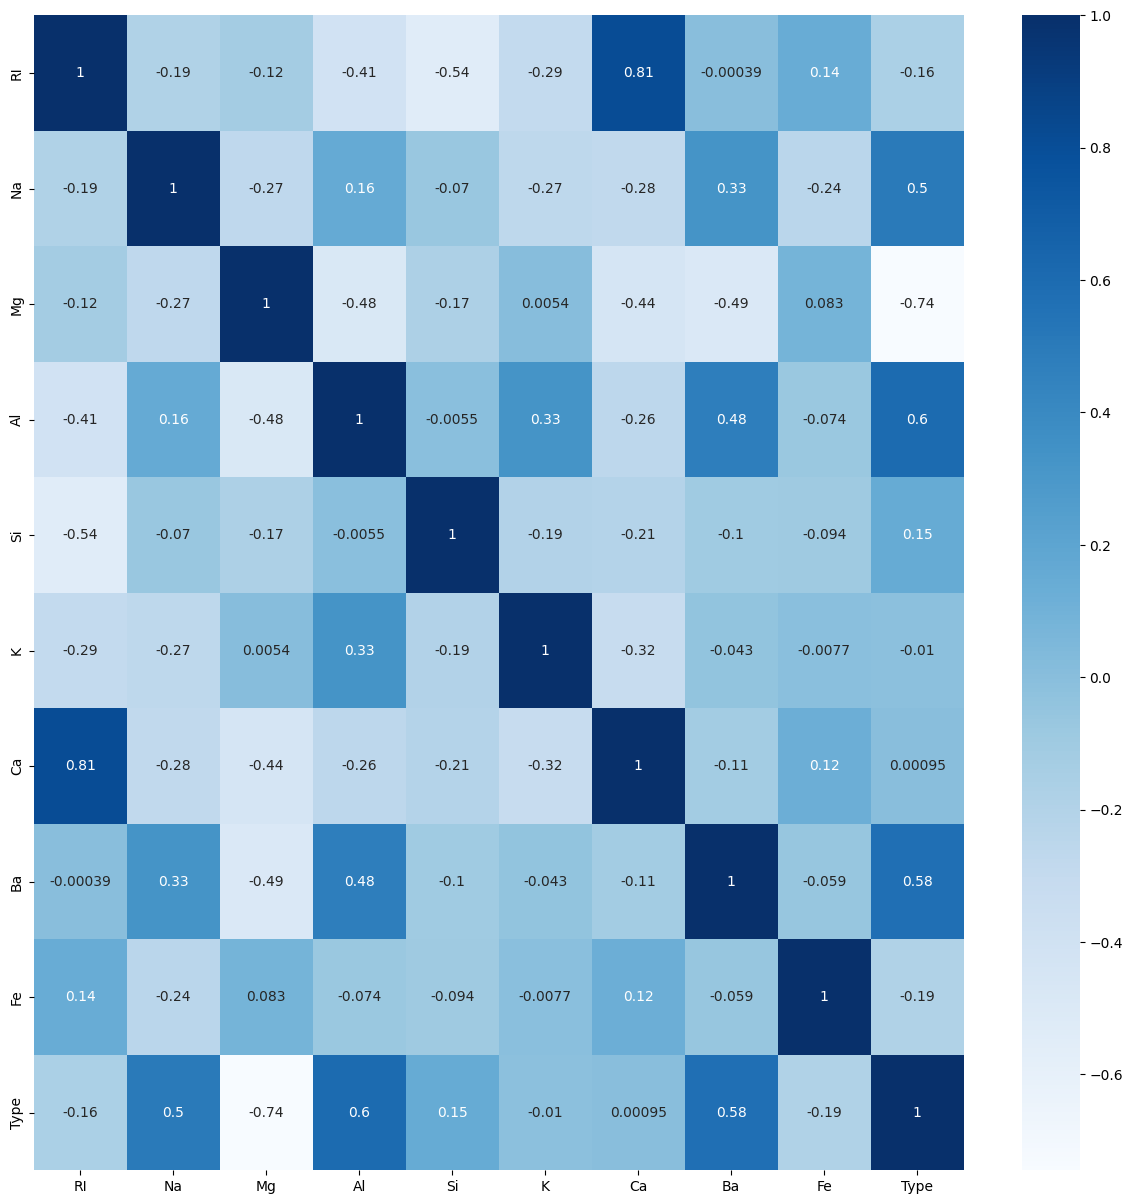

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.show()

Inferences



*   The target classes are imbalanced, and some features such as K, Ba, and Fe are highly skewed.
*   Ba and K have many observations concentrated near zero.


*   Ba, Ca, Na, Al, and K show noticeable outliers.
*   RI and Ca: +0.81 → strong positive correlation.

*   Al, Na, and Ba show noticeable relationships with the glass Type






# 3: Data Preprocessing:

Since the dataset contains no missing values, the original observations can be retained without applying a missing-value treatment.

In [ ]:
for col in df.select_dtypes(include='number').columns:
    print(col)
    print(df[col].unique())
    print("-" * 30)

RI
[1.52101 1.51761 1.51618 1.51766 1.51742 1.51596 1.51743 1.51756 1.51918
 1.51755 1.51571 1.51763 1.51589 1.51748 1.51784 1.52196 1.51911 1.51735
 1.5175  1.51966 1.51736 1.51751 1.5172  1.51764 1.51793 1.51721 1.51768
 1.51747 1.51775 1.51753 1.51783 1.51567 1.51909 1.51797 1.52213 1.51779
 1.5221  1.51786 1.519   1.51869 1.52667 1.52223 1.51898 1.5232  1.51926
 1.51808 1.51837 1.51778 1.51769 1.51215 1.51824 1.51754 1.51905 1.51977
 1.52172 1.52227 1.52099 1.52152 1.523   1.51574 1.51848 1.51593 1.51631
 1.5159  1.51645 1.51627 1.51613 1.51592 1.51646 1.51594 1.51409 1.51625
 1.51569 1.5164  1.51841 1.51605 1.51588 1.51629 1.5186  1.51689 1.51811
 1.51655 1.5173  1.5182  1.52725 1.5241  1.52475 1.53125 1.53393 1.52222
 1.51818 1.52664 1.52739 1.52777 1.51892 1.51847 1.51846 1.51829 1.51708
 1.51673 1.51652 1.51844 1.51663 1.51687 1.51707 1.52177 1.51872 1.51667
 1.52081 1.52068 1.5202  1.52614 1.51813 1.518   1.51789 1.51806 1.51711
 1.51674 1.5169  1.51851 1.51662 1.51709 1.5166 

Drop Duplicates

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

No categorical encoding is required for the predictor variables.

Scaling

StandardScaler because it transforms the features to a common scale based on their mean and standard deviation and also because there are outliers.

In [ ]:
df.select_dtypes(include='number').columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

df[num_cols] = scaler.fit_transform(df[num_cols])

The numerical features were standardized using StandardScaler because they have different scales. The target variable Type was not scaled because it represents categorical classes. Although the target classes are imbalanced, the classification report showed acceptable performance across the classes, including the minority classes. Therefore, no oversampling or undersampling was applied. Stratified train-test splitting was used to preserve the class distribution, and class weighting can be considered if minority-class performance decreases.

# 4.Random Forest Model Implementation:

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Type', axis=1)
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#Build the model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
#Train the model
rf.fit(X_train, y_train)
#Predict the model
y_pred = rf.predict(X_test)
#Evaluate the model
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.8372093023255814
Precision: 0.8465265354800238
Recall   : 0.8372093023255814
F1 Score : 0.8353266888150609


The Random Forest classifier achieved an accuracy of 83.72%, with precision, recall, and F1-score of 84.65%, 83.72%, and 83.53%, respectively. These results indicate that the Random Forest model performs well in classifying the different types of glass and provides a good balance between correctly identifying the classes and avoiding incorrect predictions.

# 5.Bagging and Boosting Methods:

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

y_pred_bag = bagging.predict(X_test)
print("Bagging Accuracy :", accuracy_score(y_test, y_pred_bag))
print("Bagging Precision:", precision_score(y_test, y_pred_bag, average='weighted'))
print("Bagging Recall   :", recall_score(y_test, y_pred_bag, average='weighted'))
print("Bagging F1 Score :", f1_score(y_test, y_pred_bag, average='weighted'))

Bagging Accuracy : 0.7906976744186046
Bagging Precision: 0.7967884828349944
Bagging Recall   : 0.7906976744186046
Bagging F1 Score : 0.7887853926346309


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

boosting = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting.fit(X_train, y_train)

y_pred_boost = boosting.predict(X_test)
print("Boosting Accuracy :", accuracy_score(y_test, y_pred_boost))
print("Boosting Precision:", precision_score(y_test, y_pred_boost, average='weighted'))
print("Boosting Recall   :", recall_score(y_test, y_pred_boost, average='weighted'))
print("Boosting F1 Score :", f1_score(y_test, y_pred_boost, average='weighted'))

Boosting Accuracy : 0.3953488372093023
Boosting Precision: 0.3852798364426271
Boosting Recall   : 0.3953488372093023
Boosting F1 Score : 0.3857333020123717


Comparison

*   Random Forest performed the best, achieving 83.72% accuracy and an F1-score of 83.53%.
*   Bagging performed reasonably well, with 79.07% accuracy, but was slightly lower than Random Forest.
*   Boosting performed poorly on this dataset, with only 39.53% accuracy.
*   Therefore, Random Forest was the best-performing ensemble method for the Glass dataset among the three models tested.





In [ ]:
print(y.value_counts().sort_index())


Type
1    69
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.81      0.93      0.87        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.83      0.83      0.82        43
weighted avg       0.85      0.84      0.84        43



# Additional Notes:
~~~
1. Explain Bagging and Boosting methods. How is it different from each other.
     Bagging (Bootstrap Aggregating) trains multiple models independently and in parallel using different random samples of the training data. Their predictions are then combined, usually by voting for classification. Bagging mainly helps reduce variance and overfitting. Random Forest is a popular example of a bagging-based method.

     Boosting trains models sequentially, where each new model focuses more on the mistakes made by the previous models. The models are then combined to produce a stronger classifier. Boosting mainly helps reduce bias and improve predictive performance. Examples include AdaBoost, Gradient Boosting, and XGBoost.
2. Explain how to handle imbalance in the data.
     Imbalanced data occurs when some classes have many more observations than other classes.
     Oversampling – Increase the number of minority-class samples, such as using SMOTE.
     Undersampling – Reduce samples from the majority class.
     Class weights – Give higher importance to minority classes during model training, for example class_weight='balanced'.
     Use appropriate evaluation metrics – Don't rely only on accuracy. Use precision, recall, F1-score, and preferably a confusion matrix to evaluate individual classes.
     Stratified splitting – Use stratify=y when splitting the data so that each class is represented proportionally in training and testing sets.